# 7. JAX backend: batched sampling and the pure forward model

Everything so far ran on the default hcipy backend. Setting `backend: jax` in a config (or `backend="jax"` on the constructors) swaps wavefront propagation onto JAX — same YAML, same correctors and outputs, same `sample()` — with results matching hcipy to float64 round-off. Install the extra with `pip install "telescope-sim[jax]"` (Python ≥ 3.11).

Under the hood, propagation runs as a jitted, wavelength-vmapped matrix Fourier transform and the corrector chain composes into a single summed pupil-plane OPD (thin phase screens commute). That pure core is what enables the two features this tutorial covers: **`sample_batch`** (one device dispatch for a whole batch) and **`forward_fn`** (a pure function you can `jit` / `vmap` / `grad` and build your own samplers on).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from telescope_sim import TelescopeSim

sim_h = TelescopeSim.from_preset("elf_15seg")
sim_j = TelescopeSim.from_preset("elf_15seg", backend="jax")

rng = np.random.default_rng(0)
ptt = rng.normal(scale=0.1, size=(15, 3))
img_h = sim_h.sample({"segments": ptt})["images"]["psf"]
img_j = sim_j.sample({"segments": ptt})["images"]["psf"]
print('cross-backend max |diff| (peak-normalized):',
      np.max(np.abs(img_j - img_h)) / img_h.max())


cross-backend max |diff| (peak-normalized): 2.916176304692551e-15


## Batched sampling

`sample_batch` takes actuation arrays with a **leading batch dimension** and returns a `sample()`-shaped dict with a batch axis on every image, echo, and Strehl value. On the jax backend the whole batch propagates as one jitted + vmapped device dispatch (the first call at a given batch shape pays the jit compile; subsequent calls reuse it — prefer a fixed batch size inside loops). On the hcipy backend the same call falls back to an equivalent Python loop, so code written against `sample_batch` is backend-portable.

images: (16, 640, 640, 1)
echoes: (16, 15, 3)
strehls: (16,)


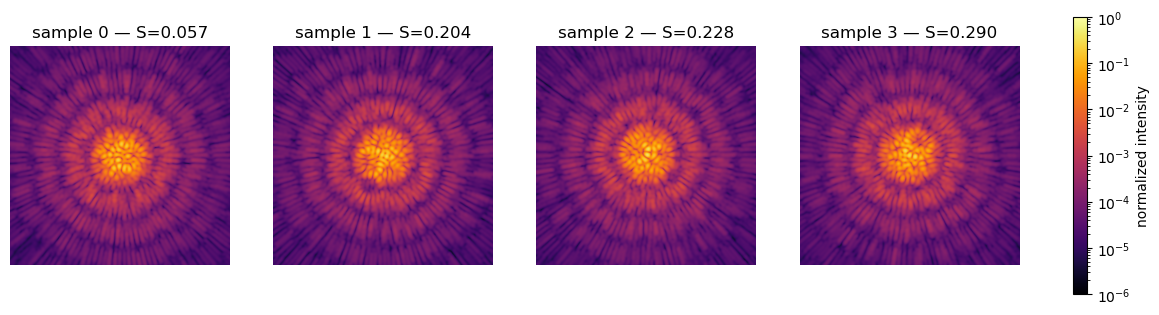

In [2]:
B = 16
ptt_batch = rng.normal(scale=0.1, size=(B, 15, 3))
batch = sim_j.sample_batch({"segments": ptt_batch}, meas_strehl=True)
print('images:', batch['images']['psf'].shape)
print('echoes:', batch['actuations']['segments'].shape)
print('strehls:', batch['strehls']['filter1'].shape)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for b, ax in enumerate(axes):
    im = ax.imshow(batch['images']['psf'][b, ..., 0], cmap='inferno',
                   norm=LogNorm(vmin=1e-6, vmax=1.0))
    ax.set_title(f"sample {b} — S={batch['strehls']['filter1'][b]:.3f}")
    ax.set_axis_off()
fig.colorbar(im, ax=list(axes), fraction=0.02, label='normalized intensity')
plt.show()


In [3]:
import time

sim_j.sample_batch({'segments': ptt_batch})  # warm the jit for this shape
t0 = time.perf_counter()
sim_j.sample_batch({'segments': ptt_batch})
t_batch = time.perf_counter() - t0
t0 = time.perf_counter()
for b in range(B):
    sim_h.sample({'segments': ptt_batch[b]})
t_loop = time.perf_counter() - t0
print(f'jax sample_batch: {1e3 * t_batch / B:.2f} ms/sample')
print(f'hcipy loop:       {1e3 * t_loop / B:.2f} ms/sample')


jax sample_batch: 50.03 ms/sample
hcipy loop:       109.27 ms/sample


Those numbers are CPU; the batch dispatch is where GPUs and the `precision: float32` config field (half-memory kernels, float32 outputs — handy for ML consumers) pay off, with no code changes: JAX picks up whatever accelerator its install supports.

## Fully on-device batches: `key=`

By default `sample_batch` runs output taps and post-processing on the host, per sample — bit-consistent with `sample()`. Passing **`key=`** (an int seed or a JAX PRNG key) moves the whole output stage into the device dispatch too: detector noise on JAX PRNG streams, convolution, normalizations, actuation echoes, and Strehl. That is the "parameters in → training data out" path: nothing round-trips through host numpy.

Noisy outputs are reproducible per key *within* the jax backend; they deliberately do **not** bit-match the host path's numpy draws (the detector's flat-field fixed pattern *is* shared, and noise-free chains match the host exactly). In key-mode, per-sample overrides like `int_phot_flux` accept arrays with a leading batch dimension — below, every sample in the batch gets its own photon flux.

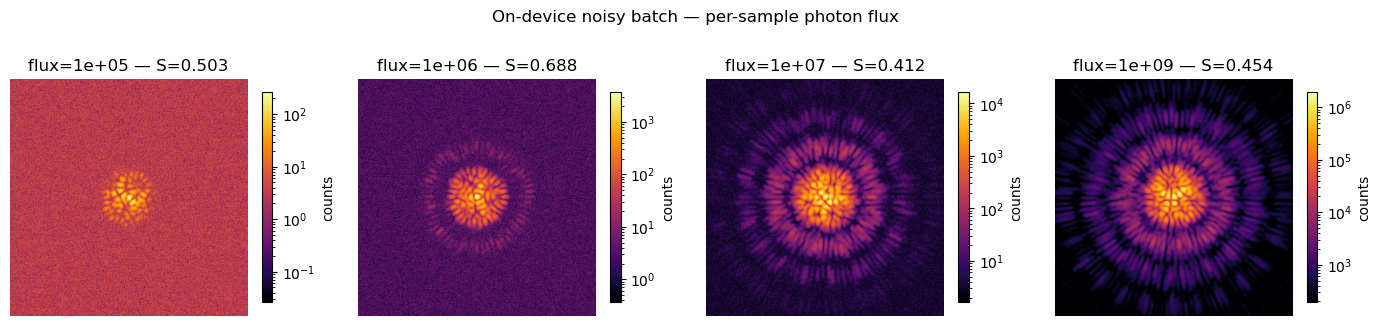

same key reproduces exactly: True


In [4]:
from telescope_sim.config.schema import SimConfig
from telescope_sim.config.loader import build

# Single-filter noisy config (noisy_detector needs exactly one
# focal grid); same sELF aperture + PTT corrector as the preset.
noisy_cfg = {
    'backend': 'jax',
    'pupil': {'resolution': 256, 'extent': 3.675},
    'aperture': {
        'type': 'segmented_circular',
        'segment_diameter': 0.5,
        'layout': 'elf', 'n_segments': 15, 'ring_radius': 1.5,
        'supersample': 16,
    },
    'correctors': {
        'segments': {
            'type': 'segmented_ptt',
            'piston_scale': 1.0e-6, 'tip_tilt_scale': 1.0e-6,
            'wavefront_role': 'actuate',
            'target_strategy': 'actuators', 'target': True,
        },
    },
    'corrector_chain': ['segments'],
    'focal_planes': {
        'filter1': {
            'type': 'angular', 'central_lam': 0.975e-6,
            'focal_extent': 3.2, 'focal_res': 640,
            'fractional_bandwidth': 0.1538, 'num_samples': 11,
        },
    },
    'outputs': {
        'psf': {
            'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
            'post_processing': [
                {'type': 'noisy_detector',
                 'int_phot_flux': 1.0e7,
                 'detector': {
                     'read_noise': 5.0,
                     'dark_current_rate': 0.0,
                     'flat_field': 0.0,
                     'include_photon_noise': True,
                 }},
            ],
        },
    },
    'strehl_method': 'matched_filter',
    'strehl_core_rad': 1.2e-6,
}
noisy_sim = build(SimConfig.model_validate(noisy_cfg))

fluxes = np.array([1.0e5, 1.0e6, 1.0e7, 1.0e9])
batch4 = rng.normal(scale=0.1, size=(4, 15, 3))
out = noisy_sim.sample_batch(
    {'segments': batch4},
    key=0,
    output_overrides={'psf': {'int_phot_flux': fluxes}},
    meas_strehl=True,
)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for b, ax in enumerate(axes):
    img = out['images']['psf'][b, ..., 0]
    vmax = float(img.max())
    floor = max(vmax * 1e-4, 1e-3)
    # Clip zero-count pixels to the LogNorm floor (zeros are 'bad'
    # under LogNorm and would render as blank specks).
    im = ax.imshow(np.maximum(img, floor), cmap='inferno',
                   norm=LogNorm(vmin=floor, vmax=vmax))
    ax.set_title(f"flux={fluxes[b]:.0e} — S={out['strehls']['filter1'][b]:.3f}")
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7, label='counts')
fig.suptitle('On-device noisy batch — per-sample photon flux')
plt.tight_layout()
plt.show()

again = noisy_sim.sample_batch(
    {'segments': batch4}, key=0,
    output_overrides={'psf': {'int_phot_flux': fluxes}},
)
print('same key reproduces exactly:',
      np.array_equal(out['images']['psf'], again['images']['psf']))


## The pure forward model: `forward_fn`

`sample_batch` is a *reference composition* — curriculum samplers, temporal sequences, RL loops, and DataLoader-style pipelines should compose the primitive underneath it instead: `sim.forward_fn()` returns a pure, jit/vmap/grad-compatible function from caller-facing actuation values to raw summed focal-plane intensities, with the two stages exposed separately:

- `opd_from_actuations(acts)` → total pupil-plane OPD (meters)
- `intensity_from_opd(opd)` → per-focal-plane raw intensity — and the hook for **external OPD**: add an atmosphere screen or any extra pupil OPD to the actuation OPD before this stage

plus `actuation_echo(acts)` (training-target echoes) and `strehls_from_intensities(...)` (in-graph Strehl). Because the forward is pure, gradients flow through the full optical model — the demo below recovers the sensitivity of Strehl to every piston/tip/tilt command in one `jax.grad` call.

In [5]:
import jax

fwd = sim_j.forward_fn()
print('inputs:', fwd.corrector_names, fwd.n_actuators)
print('focal planes:', fwd.focal_plane_names)

# Stage decomposition: actuations -> OPD -> intensities
opd = fwd.opd_from_actuations({'segments': ptt})
images = fwd.intensity_from_opd(opd)
print('opd:', opd.shape, '-> intensity:', images['filter1'].shape)

# Gradient of Strehl w.r.t. every PTT command, through the full model
def neg_strehl(acts):
    intensities = fwd({'segments': acts})
    return -fwd.strehls_from_intensities(intensities)['filter1']

grads = jax.grad(neg_strehl)(ptt)
print('d(-Strehl)/d(ptt):', np.asarray(grads).shape)

# vmap composes the same way sample_batch does internally
batched_fwd = jax.jit(jax.vmap(fwd))
raw = batched_fwd({'segments': ptt_batch})
print('vmapped raw intensities:', raw['filter1'].shape)


inputs: ('segments',) {'segments': 45}
focal planes: ('filter1',)
opd: (65536,) -> intensity: (640, 640)


d(-Strehl)/d(ptt): (15, 3)


vmapped raw intensities: (16, 640, 640)


## Fit-role correctors are part of the graph

Chains with `wavefront_role: fit` correctors work through `forward_fn` and `sample_batch` too: at build time the corrector's least-squares `fit_surface` is probed through every upstream corrector's contribution map (*composed-fit probing*), so the fit state — and residual-fit training echoes — become precomputed linear maps of the input actuations. No host round-trip per sample.

One boundary to know: the composed fit responds to *actuation-driven* OPD only. External OPD added at the `intensity_from_opd` hook bypasses fit-role correctors — for atmosphere the fit should react to (and cancel), use `sample(atmos=...)`.

Below, an imposed Zernike DM disturbs the wavefront and a second, fit-role Zernike DM cancels it inside the graph: the batch comes back at the reference Strehl, and the echo reports the fitted (matching) state of the disturbance.

In [6]:
fit_cfg = {
    'backend': 'jax',
    'pupil': {'resolution': 128, 'extent': 1.05},
    'aperture': {
        'type': 'external_pupil', 'module': 'hcipy',
        'function': 'make_circular_aperture', 'mode': 'callable',
        'kwargs': {'diameter': 1.0}, 'area': 0.7853981633974483,
    },
    'correctors': {
        'disturbance': {
            'type': 'zernike', 'n_modes': 8, 'zernike_diameter': 1.0,
            'starting_mode': 2, 'actuate_scale': 5.0e-8,
            'wavefront_role': 'impose',
        },
        'ao_dm': {
            'type': 'zernike', 'n_modes': 8, 'zernike_diameter': 1.0,
            'starting_mode': 2, 'actuate_scale': 5.0e-8,
            'wavefront_role': 'fit',
            'fit_source': 'cumulative_phase_pre_self',
            'target_strategy': 'actuators', 'target': True,
        },
    },
    'corrector_chain': ['disturbance', 'ao_dm'],
    'focal_planes': {
        'filter1': {
            'type': 'angular', 'central_lam': 1.0e-6,
            'focal_extent': 2.0, 'focal_res': 64,
        },
    },
    'outputs': {
        'psf': {'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
                'post_processing': []},
    },
    'strehl_method': 'matched_filter',
    'strehl_core_rad': 4.0e-6,
}
fit_sim = build(SimConfig.model_validate(fit_cfg))

zernike_batch = rng.normal(size=(8, 8))
corrected = fit_sim.sample_batch({'disturbance': zernike_batch},
                                 key=0, meas_strehl=True)
print('Strehl with in-graph AO fit :', corrected['strehls']['filter1'].round(6))
print('echo (fitted disturbance) vs commands, max |diff|:',
      np.max(np.abs(-corrected['actuations']['ao_dm'] - zernike_batch)))


Strehl with in-graph AO fit : [1. 1. 1. 1. 1. 1. 1. 1.]
echo (fitted disturbance) vs commands, max |diff|: 8.960889030795727e-07


## Notes

- **Parity is pinned by tests**: cross-backend images agree at 1e-12 (observed ~1e-15) on every supported chain, and the legacy-parity golden fixtures pass on the jax backend at the same tolerances as hcipy.
- **jit recompiles per batch shape** — keep batch sizes fixed (or pad) inside training loops.
- Components with no JAX path (the `fiber_dual` tap, atmospheres without `.phase_for`) are rejected at config time with clear errors; the hcipy backend remains the fully general path.
- Custom linear correctors work automatically: the backend probes `set_actuators` numerically at build time, so anything whose surface is linear in its commands folds into the forward map with no extra code.